# Phase II — Boundary-Based and Non-linear Classification
**ChestMNIST: pleural effusion absent/present.**

Train decision trees, boosted trees, linear soft-margin SVMs and RBF SVMs. Compare their validation and test metrics with Phase I. Plot feature importance and illustrative 2D decision boundaries.

Use the same Python environment as Phase I. Run cells in order. All tuning uses validation data; test data is used after configurations are fixed. This phase does not add label noise.

In [1]:
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay)

cwd = Path.cwd()
ROOT = next((p for p in (cwd, cwd.parent) if (p / 'chestmnist(1)').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook from TP1 or its phase_2 folder.')
DATA = ROOT / 'chestmnist(1)'
P1 = ROOT / 'phase_1' / 'outputs'
OUT = ROOT / 'phase_2' / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)
config = json.loads((P1 / 'phase1_config.json').read_text())
SEED = config['seed']
LABEL = config['label_index']
assert LABEL == 2 and config['target'] == 'effusion'
indices = np.load(P1 / 'train_indices.npy', allow_pickle=False)
print('Outputs:', OUT.resolve())

Outputs: /home/raoul-ossombe/Desktop/2026-2027/deep learning/TP1/phase_2/outputs


## 1. Reuse Phase I data and preprocessing
The saved training indices are essential: changing the subset would change the comparison. Scaling and PCA are fitted on training data only. All main models use the same 50-component representation as Phase I.

PCA components combine original pixels. Their feature importance is not a direct anatomical explanation.

In [2]:
def load(split):
    images = np.load(DATA / f'{split}_images.npy', mmap_mode='r', allow_pickle=False)
    labels = np.load(DATA / f'{split}_labels.npy', mmap_mode='r', allow_pickle=False)
    assert images.shape[1:] == (28, 28)
    assert labels.shape == (len(images), 14)
    return images, labels[:, LABEL].astype(int)

def flatten(images):
    return np.asarray(images, dtype=np.float32).reshape(len(images), -1) / 255.0

train_images, all_y = load('train')
val_images, y_val = load('val')
assert indices.ndim == 1 and len(np.unique(indices)) == len(indices)
assert indices.min() >= 0 and indices.max() < len(train_images)
X_train, y_train = flatten(train_images[indices]), all_y[indices]
X_val = flatten(val_images)
assert len(y_train) == config['actual_train']
preprocessing = Pipeline([('scale', StandardScaler()),
    ('pca', PCA(n_components=50, svd_solver='randomized', random_state=SEED))])
Z_train = preprocessing.fit_transform(X_train)
Z_val = preprocessing.transform(X_val)
joblib.dump(preprocessing, OUT / 'preprocessing.joblib')
print('Training:', Z_train.shape, 'class counts:', np.bincount(y_train))
print('PCA explained variance:', preprocessing['pca'].explained_variance_ratio_.sum())

Training: (10000, 50) class counts: [8820 1180]
PCA explained variance: 0.9531094


## 2. Decision trees and boosting (Task 2.1)
CART chooses binary splits that reduce impurity; here we use Gini impurity. Depth control and a minimum leaf size limit memorization. A rough training-cost description is O(n × m × depth), although sorting and implementation details affect actual cost.

Gradient boosting adds shallow trees sequentially to reduce the classification loss. It can capture complex patterns but may learn mislabeled examples. Tune a small depth grid tonight; other parameters remain fixed.

## 3. Linear and kernel SVMs (Task 2.2)
A linear SVM chooses a separating hyperplane with a wide margin. This dataset is not perfectly separable, so we use a soft margin: C controls the penalty for violations. Smaller C means stronger regularization; larger C prioritizes fitting training examples.

LinearSVC uses a dedicated linear solver for scalable soft-margin training; it does not expose support-vector indices. RBF SVC exposes the support vectors. The RBF kernel, exp(-gamma × squared distance), defines nonlinear similarity without explicitly constructing a high-dimensional feature map. Gamma controls locality. SVM decision scores are sufficient for ROC-AUC and AP; they are not probabilities. The default classification threshold is zero.

In [3]:
def evaluate(y, prediction, score):
    return {'accuracy': accuracy_score(y, prediction),
        'precision': precision_score(y, prediction, zero_division=0),
        'recall': recall_score(y, prediction, zero_division=0),
        'f1': f1_score(y, prediction, zero_division=0),
        'roc_auc': roc_auc_score(y, score),
        'average_precision': average_precision_score(y, score)}

def scores(model, X):
    return model.decision_function(X) if hasattr(model, 'decision_function') else model.predict_proba(X)[:, 1]

candidates = {}
for depth in (3, 5, 10):
    candidates[f'Tree_depth{depth}'] = ('Decision tree', DecisionTreeClassifier(
        max_depth=depth, min_samples_leaf=10, random_state=SEED))
for depth in (1, 2, 3):
    candidates[f'Boost_depth{depth}'] = ('Gradient boosting', GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=depth, random_state=SEED))
for C in (0.1, 1, 10):
    candidates[f'LinearSVM_C{C}'] = ('Linear SVM', LinearSVC(C=C, dual=False, max_iter=10000, random_state=SEED))
    for gamma in ('scale', 0.001):
        candidates[f'RBFSVM_C{C}_gamma{gamma}'] = ('RBF SVM', SVC(
            kernel='rbf', C=C, gamma=gamma, cache_size=256))

fitted, validation_rows = {}, []
for name, (family, model) in candidates.items():
    start = time.perf_counter()
    model.fit(Z_train, y_train)
    fit_time = time.perf_counter() - start
    start = time.perf_counter()
    prediction, score = model.predict(Z_val), scores(model, Z_val)
    prediction_time = time.perf_counter() - start
    validation_rows.append({'family': family, 'model': name,
        'fit_seconds': fit_time, 'validation_inference_seconds': prediction_time,
        **evaluate(y_val, prediction, score)})
    fitted[name] = model
    pd.DataFrame(validation_rows).to_csv(OUT / 'validation_progress.csv', index=False)
    print(name, 'completed', flush=True)
validation_results = pd.DataFrame(validation_rows).sort_values('average_precision', ascending=False)
validation_results.to_csv(OUT / 'validation_metrics.csv', index=False)
display(validation_results)
selected = {family: rows.iloc[0]['model'] for family, rows in
            validation_results.groupby('family', sort=False)}
(OUT / 'selected_models.json').write_text(json.dumps(selected, indent=2))
print('Configurations selected by validation AP:', selected)

Tree_depth3 completed


Tree_depth5 completed


Tree_depth10 completed


Boost_depth1 completed


Boost_depth2 completed


...

LinearSVM_C10 completed


RBFSVM_C10_gammascale completed


RBFSVM_C10_gamma0.001 completed


,family,model,fit_seconds,validation_inference_seconds,accuracy,precision,recall,f1,roc_auc,average_precision
5,Gradient boosting,Boost_depth3,9.962745,0.026928,0.884749,0.333333,0.000774,0.001544,0.753221,0.263275
6,Linear SVM,LinearSVM_C0.1,0.066017,0.001894,0.884749,0.400000,0.001548,0.003084,0.746584,0.254137
9,Linear SVM,LinearSVM_C1,0.061729,0.001438,0.884749,0.400000,0.001548,0.003084,0.746579,0.254130
12,Linear SVM,LinearSVM_C10,0.079385,0.010034,0.884749,0.400000,0.001548,0.003084,0.746581,0.254127
4,Gradient boosting,Boost_depth2,6.967887,0.020859,0.884838,0.000000,0.000000,0.000000,0.747281,0.252553
3,Gradient boosting,Boost_depth1,3.619238,0.014179,0.884838,0.000000,0.000000,0.000000,0.729922,0.241556
10,RBF SVM,RBFSVM_C1_gammascale,2.262755,3.695009,0.884838,0.000000,0.000000,0.000000,0.697767,0.234374
7,RBF SVM,RBFSVM_C0.1_gammascale,2.054820,3.712451,0.884838,0.000000,0.000000,0.000000,0.697703,0.233984
14,RBF SVM,RBFSVM_C10_gamma0.001,2.833049,3.884458,0.879668,0.345745,0.050310,0.087838,0.697263,0.229597
11,RBF SVM,RBFSVM_C1_gamma0.001,2.152250,3.536547,0.884838,0.000000,0.000000,0.000000,0.696287,0.229595


Configurations selected by validation AP: {'Gradient boosting': 'Boost_depth3', 'Linear SVM': 'LinearSVM_C0.1', 'RBF SVM': 'RBFSVM_C1_gammascale', 'Decision tree': 'Tree_depth5'}


## 4. Tree interpretation
Importance measures total normalized impurity reduction for PCA components. It is descriptive, can be biased, and is not causal evidence of a medical finding. The diagram displays only the first two levels of the fitted tree.

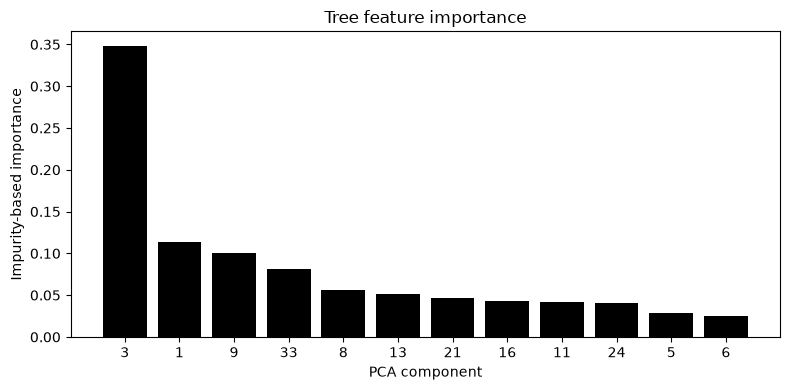

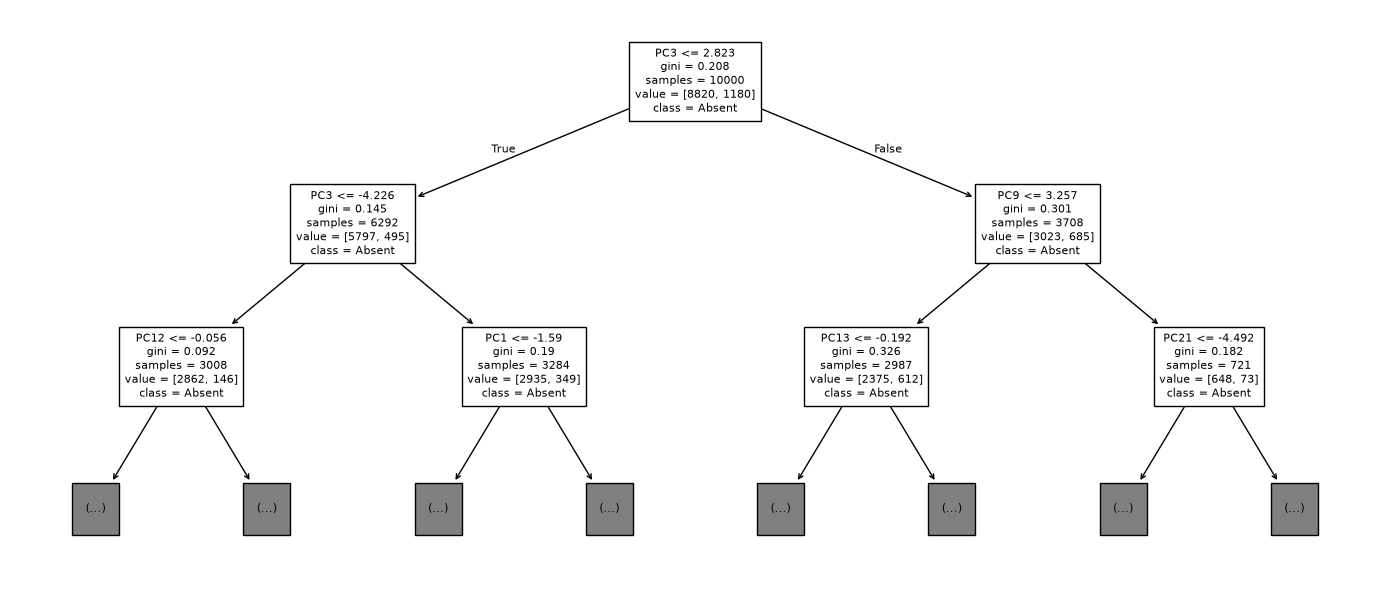

RBF SVM support vectors per class: [2648 1180]


In [4]:
tree = fitted[selected['Decision tree']]
importance = pd.DataFrame({'component': np.arange(1, 51),
    'importance': tree.feature_importances_}).sort_values('importance', ascending=False)
importance.to_csv(OUT / 'tree_feature_importance.csv', index=False)
fig, ax = plt.subplots(figsize=(8, 4))
top = importance.head(12)
ax.bar(top.component.astype(str), top.importance, color='black')
ax.set(xlabel='PCA component', ylabel='Impurity-based importance', title='Tree feature importance')
fig.tight_layout(); fig.savefig(OUT / 'tree_feature_importance.png', dpi=150); plt.show()
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(tree, max_depth=2, feature_names=[f'PC{i+1}' for i in range(50)],
          class_names=['Absent', 'Present'], filled=False, fontsize=8, ax=ax)
fig.tight_layout(); fig.savefig(OUT / 'tree_first_levels.png', dpi=150); plt.show()
for family in ('RBF SVM',):
    model = fitted[selected[family]]
    print(family, 'support vectors per class:', model.n_support_)

## 5. Final test metrics and Phase I comparison
Selections are now fixed. Do not retune from test results. Phase II fit_seconds measures model fitting alone, whereas Phase I included preprocessing. To avoid misleading time comparisons, report shared preprocessing separately or explicitly distinguish the scopes.

Trees use probability 0.5 as their usual decision cutoff (ties may follow class order); SVMs use score zero. These default decisions need not yield high recall.

In [5]:
test_images, y_test = load('test')
Z_test = preprocessing.transform(flatten(test_images))
test_rows, test_scores = [], {}
for family, name in selected.items():
    model = fitted[name]
    start = time.perf_counter()
    prediction, score = model.predict(Z_test), scores(model, Z_test)
    inference_time = time.perf_counter() - start
    fit_time = validation_results.loc[validation_results.model == name, 'fit_seconds'].iloc[0]
    test_rows.append({'family': family, 'model': name, 'fit_seconds': fit_time,
        'test_inference_seconds': inference_time, **evaluate(y_test, prediction, score)})
    test_scores[family] = score
    # Save a full inference pipeline containing the already fitted transformation.
    joblib.dump(Pipeline([('preprocessing', preprocessing), ('model', model)]),
                OUT / (name + '.joblib'))
test_results = pd.DataFrame(test_rows)
test_results.to_csv(OUT / 'test_metrics.csv', index=False)
display(test_results)

p1_test = pd.read_csv(P1 / 'test_metrics.csv').assign(phase='I')
p2_test = test_results.assign(phase='II')
metric_columns = ['phase', 'family', 'model', 'accuracy', 'precision', 'recall',
                  'f1', 'roc_auc', 'average_precision']
combined = pd.concat([p1_test[metric_columns], p2_test[metric_columns]], ignore_index=True)
combined.to_csv(OUT / 'combined_test_metrics.csv', index=False)
display(combined)
# Phase III selection must use validation, not the combined test ranking.
p1_val = pd.read_csv(P1 / 'validation_metrics.csv')
p1_selected = json.loads((P1 / 'selected_models.json').read_text())
p1_val = p1_val[p1_val.model.isin(p1_selected.values())].copy()
p1_val['family'] = p1_val.model.map({v: k for k, v in p1_selected.items()})
p2_val = validation_results[validation_results.model.isin(selected.values())]
ranking = pd.concat([p1_val[['family','model','average_precision']],
                     p2_val[['family','model','average_precision']]], ignore_index=True)
ranking = ranking.sort_values('average_precision', ascending=False)
ranking.to_csv(OUT / 'combined_validation_ranking.csv', index=False)
display(ranking)
ranking.head(3).to_csv(OUT / 'phase3_top_three.csv', index=False)

,family,model,fit_seconds,test_inference_seconds,accuracy,precision,recall,f1,roc_auc,average_precision
0,Gradient boosting,Boost_depth3,9.962745,0.082689,0.877145,0.375000,0.001089,0.002172,0.731185,0.262792
1,Linear SVM,LinearSVM_C0.1,0.066017,0.004140,0.877324,0.625000,0.001816,0.003621,0.729142,0.263593
2,RBF SVM,RBFSVM_C1_gammascale,2.262755,8.063048,0.877234,0.000000,0.000000,0.000000,0.708567,0.268256
3,Decision tree,Tree_depth5,0.190538,0.002454,0.875986,0.088235,0.001089,0.002152,0.665846,0.195624


,phase,family,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,I,Logistic regression SGA,LogReg_SGA_lr0.001,0.875362,0.340909,0.016340,0.031185,0.715165,0.250852
1,I,Gaussian Naive Bayes,GaussianNB,0.861008,0.297778,0.097313,0.146689,0.715859,0.240193
2,I,KNN,KNN_k11,0.874114,0.328431,0.024328,0.045301,0.673514,0.203074
3,II,Gradient boosting,Boost_depth3,0.877145,0.375000,0.001089,0.002172,0.731185,0.262792
4,II,Linear SVM,LinearSVM_C0.1,0.877324,0.625000,0.001816,0.003621,0.729142,0.263593
5,II,RBF SVM,RBFSVM_C1_gammascale,0.877234,0.000000,0.000000,0.000000,0.708567,0.268256
6,II,Decision tree,Tree_depth5,0.875986,0.088235,0.001089,0.002152,0.665846,0.195624


,family,model,average_precision
3,Gradient boosting,Boost_depth3,0.263275
4,Linear SVM,LinearSVM_C0.1,0.254137
0,Gaussian Naive Bayes,GaussianNB,0.244963
1,Logistic regression SGA,LogReg_SGA_lr0.001,0.236945
5,RBF SVM,RBFSVM_C1_gammascale,0.234374
2,KNN,KNN_k11,0.213658
6,Decision tree,Tree_depth5,0.200561


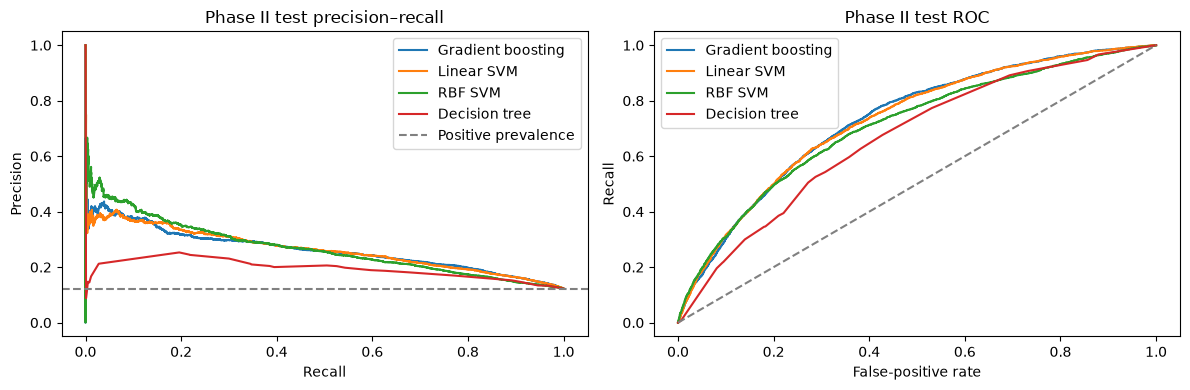

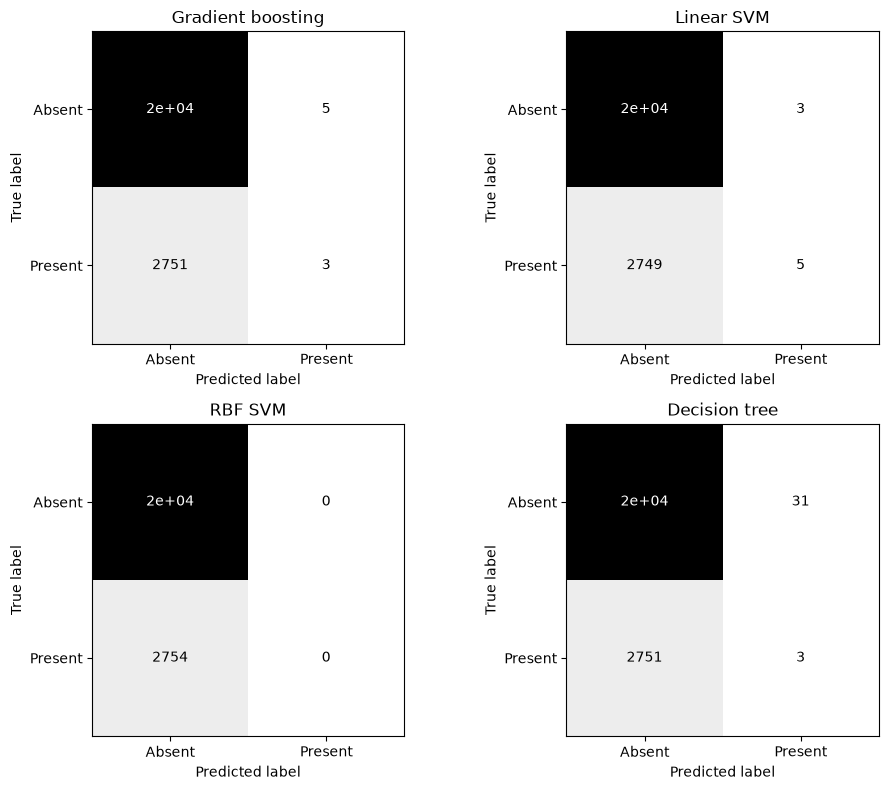

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for family, score in test_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, score)
    fpr, tpr, _ = roc_curve(y_test, score)
    axes[0].plot(recall, precision, label=family)
    axes[1].plot(fpr, tpr, label=family)
axes[0].axhline(y_test.mean(), color='gray', linestyle='--', label='Positive prevalence')
axes[1].plot([0,1],[0,1], '--', color='gray')
axes[0].set(xlabel='Recall', ylabel='Precision', title='Phase II test precision–recall')
axes[1].set(xlabel='False-positive rate', ylabel='Recall', title='Phase II test ROC')
for ax in axes: ax.legend()
fig.tight_layout(); fig.savefig(OUT / 'test_curves.png', dpi=150); plt.show()
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (family, name) in zip(axes.flat, selected.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, fitted[name].predict(Z_test),
        display_labels=['Absent', 'Present'], ax=ax, cmap='Greys', colorbar=False)
    ax.set_title(family)
fig.tight_layout(); fig.savefig(OUT / 'test_confusion_matrices.png', dpi=150); plt.show()

## 6. Two-dimensional decision boundaries (Task 2.3)
Fit a separate PCA with two components, then train a logistic regression and a tree on that representation. These are illustration models, not the main 50-component benchmark models. Logistic regression creates a straight boundary; the tree creates rectangular regions through threshold splits.

The demonstration uses balanced class weights to make both prediction regions visible. That setting is specific to this illustration, and no benchmark claims should be based on it. Two-dimensional PCA discards information and the graph is not a clinical explanation.

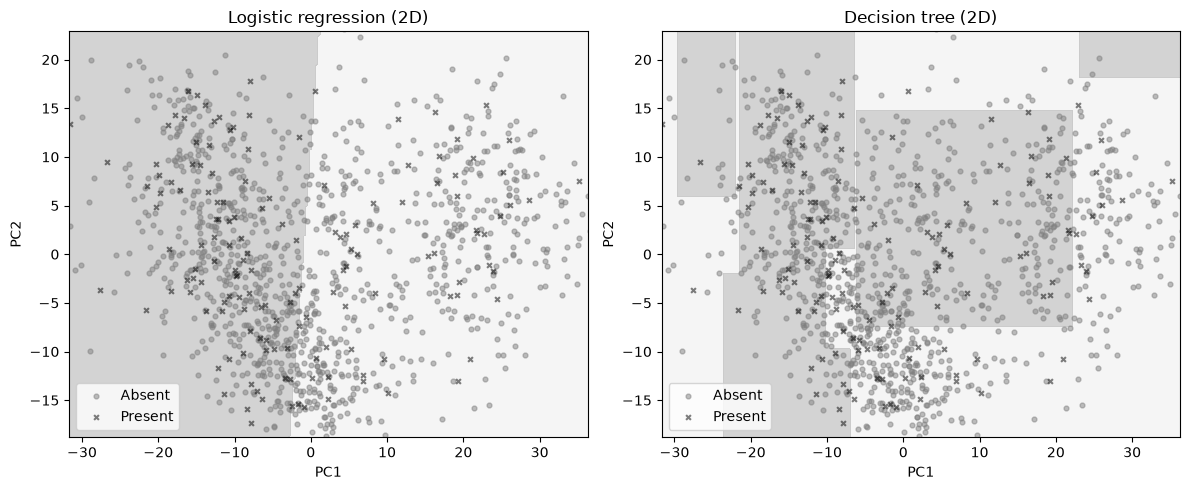

In [7]:
projection = Pipeline([('scale', StandardScaler()),
    ('pca', PCA(n_components=2, svd_solver='randomized', random_state=SEED))])
X2 = projection.fit_transform(X_train)
illustration_models = {'Logistic regression (2D)': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED),
    'Decision tree (2D)': DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
        class_weight='balanced', random_state=SEED)}
lo, hi = np.quantile(X2, 0.01, axis=0)-1, np.quantile(X2, 0.99, axis=0)+1
xx, yy = np.meshgrid(np.linspace(lo[0], hi[0], 250), np.linspace(lo[1], hi[1], 250))
grid = np.column_stack([xx.ravel(), yy.ravel()])
rng = np.random.default_rng(SEED)
shown = rng.choice(len(X2), min(1200, len(X2)), replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, illustration_models.items()):
    model.fit(X2, y_train)
    region = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, region, levels=[-0.5,0.5,1.5], cmap='Greys', alpha=0.25)
    for cls, marker in ((0,'o'), (1,'x')):
        idx = shown[y_train[shown] == cls]
        ax.scatter(X2[idx,0], X2[idx,1], s=12, marker=marker,
            color='gray' if cls == 0 else 'black', alpha=0.5,
            label='Absent' if cls == 0 else 'Present')
    ax.set(xlim=(lo[0],hi[0]), ylim=(lo[1],hi[1]), xlabel='PC1', ylabel='PC2', title=name)
    ax.legend()
fig.tight_layout(); fig.savefig(OUT / 'decision_boundaries_2d.png', dpi=150); plt.show()

## 7. Interpretation and handoff
After execution, use the measured tables to explain the effect of tree depth, boosting, C and gamma. Compare ranking metrics with recall and F1 at default thresholds. Support-vector counts describe the fitted SVM, not medical relevance.

Give Phase III the original Phase I indices, the selected model parameters, saved inference pipelines and combined validation ranking. The three strongest families are selected from validation AP across both phases. Never select them by test performance.

Saved joblib artifacts should be loaded only from trusted sources. Their portability depends on package versions. Record software versions with experiment results.

In [8]:
import sklearn, sys
versions = {'python': sys.version, 'numpy': np.__version__, 'scikit_learn': sklearn.__version__,
    'seed': SEED, 'preprocessing': config['preprocessing'], 'target': config['target'],
    'train_count': len(y_train), 'noise': 'none added',
    'fit_seconds_scope': 'Phase II model only; Phase I includes preprocessing'}
(OUT / 'phase2_config.json').write_text(json.dumps(versions, indent=2))
print('All Phase II outputs:', OUT.resolve())

All Phase II outputs: /home/raoul-ossombe/Desktop/2026-2027/deep learning/TP1/phase_2/outputs
